<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/healthcare/Contours_detection_BUSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast cancer
These are images comming from patients
What is breast cancer?
these are Ultra sound image
Why we study ultra sound images?
Clienical chalange --> present the physical images
Distribution in the breast,



Aim for the 3rd project
1. **Train a CNN to detect the mask**
* Yaloo -- CNN type
* A bounding box around the image & put mask
* mask is contorn radiology

After you undrestand what is the imag
2. **After detection**
* Filter the image
3. **Automatically segment(generate contorn)**
Object segmentation
* UNET --> CNN type

4. **Classify delassion into ordintion**


In [ ]:
# Train 3 diffirent model
# 1- model to detect the bounding box(Object detection)
    # * Find the bounding box of the contour--> this is your label for the datast
    # * Split the dataset in trainning and testing dataset

# 2- model to detect the contours
# 3- model to classify(final one) (malignant or benign)

In [1]:
from google.colab import drive
import os
import matplotlib.pyplot as plt
import matplotlib.image as pltimg
import numpy as np
import pandas as pd
import cv2
import torch
import re
from PIL import Image
from torchvision import transforms
from torch import nn
from time import time
import albumentations as A

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# connect to drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip"

In [ ]:
!unzip /content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip

### Task 1. Read an ultra image with respect column ->
* See the images and the mask
*  white is for boun tesho
* black is for soft tesho of the mask

In [5]:
data_path = ['benign', 'benign_mask', 'malignant', 'malignant_mask']

# check the files and folders
for path in data_path:
  for root, dirs, files in os.walk(path):
    print(f'There are {len(dirs)} directories and  {len(files)} files in "/{root}"')

There are 0 directories and  437 files in "/benign"
There are 0 directories and  455 files in "/benign_mask"
There are 0 directories and  210 files in "/malignant"
There are 0 directories and  212 files in "/malignant_mask"


In [6]:

def extract_idx(filename):
  """
  Extract index from the filename
  """
  index = re.search(r'\((\d+)\)', filename)
  if index is not None:
    return int(index.group(1))
  else: return -1

def is_valid_image(filename, prefix, is_mask=False):
  """
  Make sure the file and the pattern in the dataset match in order to avoid duplicate images
  """
  if is_mask:
    pattern = rf'{prefix} \(\d+\)_mask\.png$'
  else:
      pattern = rf'{prefix} \(\d+\)\.png$'
  return re.match(pattern, filename)

In [7]:
"""
  Clean up the images directories
  read all images in the directory -> extract only images by index in the file -> validate to remove duplicate or invalid image
  sort them based on the index
"""
benign = sorted(
    [f for f in os.listdir('benign') if extract_idx(f) != -1 and is_valid_image(f, 'benign', False)],
    key=extract_idx)
benign_mask = sorted(
    [f for f in os.listdir('benign_mask') if extract_idx(f) != -1 and is_valid_image(f, 'benign', True)],
    key=extract_idx)
malignant = sorted(
    [f for f in os.listdir('malignant') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', False)],
    key=extract_idx)
malignant_mask = sorted(
    [f for f in os.listdir('malignant_mask') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', True)],
    key=extract_idx)

In [8]:
len(benign), len(benign_mask), len(malignant), len(malignant_mask)

(437, 437, 210, 210)

In [9]:
# plot a random image from each classes
def plot_img_with_mask(depth, root):
  idx = np.random.randint(0, depth)
  fig, ax = plt.subplots(1, 5, figsize=(15, 4))

  # orignal image
  org_img = pltimg.imread(f'{root}/{root} ({idx}).png')
  # mask image
  mask_img = pltimg.imread(f'{root}_mask/{root} ({idx})_mask.png')

  # plot orinal img
  ax[0].imshow(org_img)
  ax[0].set_title(f"Orignal {root} ({idx})")
  ax[0].set_xticks([])
  ax[0].set_yticks([])

  # plot the mask img
  ax[1].imshow(mask_img)
  ax[1].set_title(f"Mask {root} ({idx})")
  ax[1].set_xticks([])
  ax[1].set_yticks([])


  print(f'maks_img shape: {mask_img.shape}')

  # add threshold for the mask image
  if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
    imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask_img

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
  contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

  # plot the contours image
  contours_img = cv2.drawContours(mask_img, contours, -1, (127,255,0), 2)
  ax[2].imshow(contours_img)
  ax[2].set_title(f"Contours {root} ({idx})")
  ax[2].set_xticks([])
  ax[2].set_yticks([])

  # masked the original image
  controus_img = org_img.copy()
  contours_org_img = cv2.drawContours(controus_img, contours, -1, (127, 255, 0), 2)
  ax[3].imshow(contours_org_img)
  ax[3].set_title(f'Masked {root} ({idx})', color='red')
  ax[3].set_xticks([])
  ax[3].set_yticks([])

  # Contours bounding box
  bound_img = org_img.copy()
  for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(bound_img, (x, y), (x+w, y+h), (0, 255, 0, 0), 4)
  ax[4].imshow(bound_img)
  ax[4].set_title(f'Bounding Contours {root} ({idx})', color='red')
  ax[4].set_xticks([])
  ax[4].set_yticks([])

  plt.tight_layout()


maks_img shape: (470, 555)
maks_img shape: (464, 591)


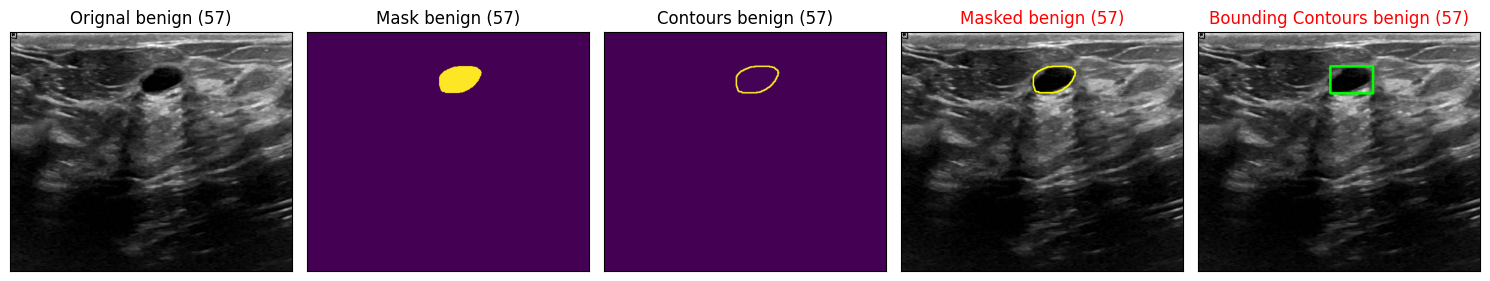

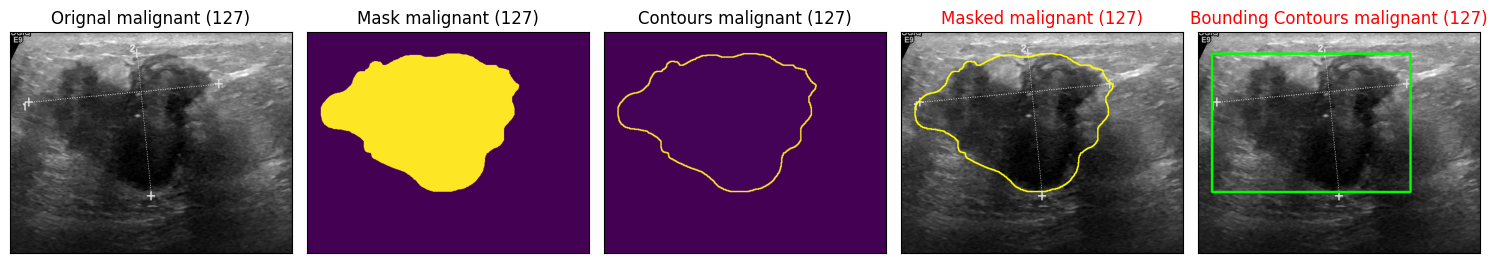

In [11]:
plot_img_with_mask(len(benign), 'benign')
plot_img_with_mask(len(malignant), 'malignant')

511 149 111 54


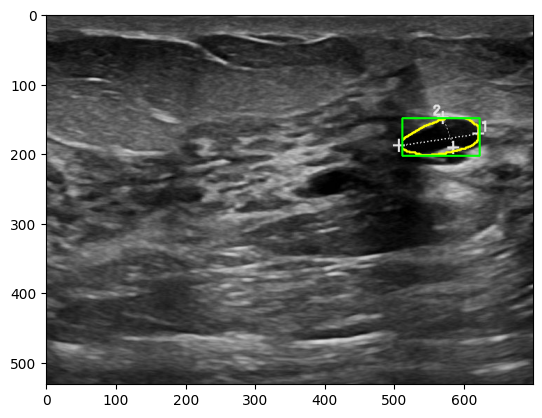

In [12]:
# add threshold for the mask image
# orignal image
org_img = pltimg.imread(f'benign/benign (14).png')
# mask image
mask_img = pltimg.imread(f'benign_mask/benign (14)_mask.png')

if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
  imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
else:
  imgray = mask_img

imgray = (imgray * 255).astype("uint8") # <-- change image type
_, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

contours_org_img = cv2.drawContours(org_img, contours, -1, (127, 255, 0), 2)
for cnt in contours:
  x, y, w, h = cv2.boundingRect(cnt)
  print(x, y, w, h)
  cv2.rectangle(contours_org_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(contours_org_img)


In [8]:
g_mean = [0.485, 0.456, 0.406]
g_std = [0.229, 0.224, 0.225]
def denormalize(img):
    if isinstance(img, torch.Tensor):
        mean = torch.tensor(g_mean, device=img.device)
        std = torch.tensor(g_std, device=img.device)
        return img * std[:, None, None] + mean[:, None, None]

    elif isinstance(img, np.ndarray):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        return img * std[None, None, :] + mean[None, None, :]

In [9]:
def get_bbox_and_cnt(mask):
  if len(mask.shape) == 3:
    imgray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)

  # get the contours
  contours, _ = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
  if len(contours)==0:
    return None

  # take the largest contour
  cnt = max(contours, key=cv2.contourArea)
  # get the bounding box
  x, y, w, h = cv2.boundingRect(cnt)

  return contours, [x, y, w, h]


In [10]:
# splitting the Benign to training and testing
def split_dataset(data):
  train_size = int(0.7 * len(data)) # 70%
  valid_size = int(0.2 * len(data)) # 20%
  test_size = len(data) - train_size - valid_size # 10%
  generator = torch.Generator().manual_seed(0)
  train, val, test = torch.utils.data.random_split(data, [train_size, valid_size, test_size], generator=generator)
  # train = torch.utils.data.Subset(data, range(0, train_size))
  # val = torch.utils.data.Subset(data, range(train_size, train_size + valid_size))
  # test = torch.utils.data.Subset(data, range(train_size + valid_size, len(data)))
  return train, val, test

In [11]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self, img_list, mask_list, img_dir, mask_dir, transform=None):
    self.img_list = img_list
    self.mask_list = mask_list
    self.img_dir = img_dir
    self.mask_dir = mask_dir
    self.transform = transform

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    image_path = os.path.join(self.img_dir, self.img_list[index])
    mask_path = os.path.join(self.mask_dir, self.mask_list[index])

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    image = np.array(image)
    mask = np.array(mask).astype(np.float32)/255.

    if self.transform:
      result = self.transform(image=image, mask=mask)
      image = result['image'].float()
      mask = (result['mask']>0).float() # <-- Make sure mask is still binary (0 or 1)

    return image, mask


In [12]:
# Create a Augmentation Pipeline
img_size = 300
train_transform_pipeline = A.Compose([
    A.Resize(img_size, img_size),

    # Geometric
    A.HorizontalFlip(p=0.2),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.3
    ),

    A.ElasticTransform(alpha=1, sigma=50, p=0.2), # Simulates tissue deformation
    A.GridDistortion(p=0.2),

    # Light intensity changes
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(std_range=(0.1, 0.5), p=0.1),

    A.GaussianBlur(
         sigma_limit=(0.2, 0.5),  # Small sigma for subtle blur
         blur_limit=0,            # Auto-compute kernel size
         p=0.2
     ),

    A.Normalize(mean=g_mean, std=g_std ),
    A.pytorch.ToTensorV2(),
])
validation_transform_pipeline = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=g_mean, std=g_std ),
    A.pytorch.ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [13]:
# Get all the dataset
train_data, val_data, test_data = split_dataset(benign)
train_mask, val_mask, test_mask = split_dataset(benign_mask)
benign_train = Dataset(train_data, train_mask, 'benign', 'benign_mask', transform=train_transform_pipeline)
benign_val = Dataset(val_data, val_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline)

In [14]:
benign[10], benign_mask[10], len(train_data), len(train_mask), len(benign_val)

('benign (11).png', 'benign (11)_mask.png', 305, 305, 87)

((300, 300, 3), torch.Size([300, 300]))

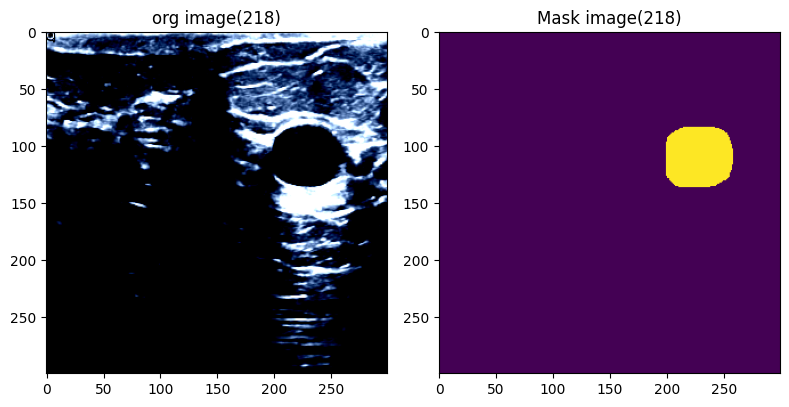

In [29]:
rand_idx = np.random.randint(0, len(benign_train))
img, label = benign_train.__getitem__(rand_idx)
img = img.permute(1,2,0).cpu().numpy()
_, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow((img))
ax[0].set_title(f"org image({rand_idx})")

ax[1].imshow(label)
ax[1].set_title(f"Mask image({rand_idx})")

plt.tight_layout()

img.shape, label.shape

In [18]:
len(benign_train), len(benign_val)

(305, 87)

In [15]:
start_time = time()
train_dir = "benign_dataset/train"
val_dir = "benign_dataset/val"
# create directory if it doesn't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
for i in range(len(benign_train)):
    tr_image, tr_label = benign_train[i]   # <-- NOW data is loaded
    torch.save((tr_image, tr_label), f"{train_dir}/benign_{i}.pt")

for i in range(len(benign_val)):
    val_image, val_label = benign_val[i]
    torch.save((val_image, val_label), f"{val_dir}/benign_{i}.pt")
print(f'tokes {time()-start_time}s')

tokes 6.947532653808594s


In [16]:
class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir):
        self.files = os.listdir(data_dir)
        self.data_dir = data_dir

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.data_dir, self.files[idx])
        image, mask = torch.load(path, weights_only=False)
        return image, mask

In [17]:
train_dataset = CachedDataset(train_dir)
val_dataset = CachedDataset(val_dir)
len(train_dataset), len(val_dataset)

(305, 87)

In [37]:
# add data loader
ben_train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=32, num_workers=2, shuffle=True, drop_last=True)
ben_valid_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=32, num_workers=2, shuffle=True)

In [23]:
len(ben_train_loader.dataset), len(ben_valid_loader.dataset)

(305, 87)

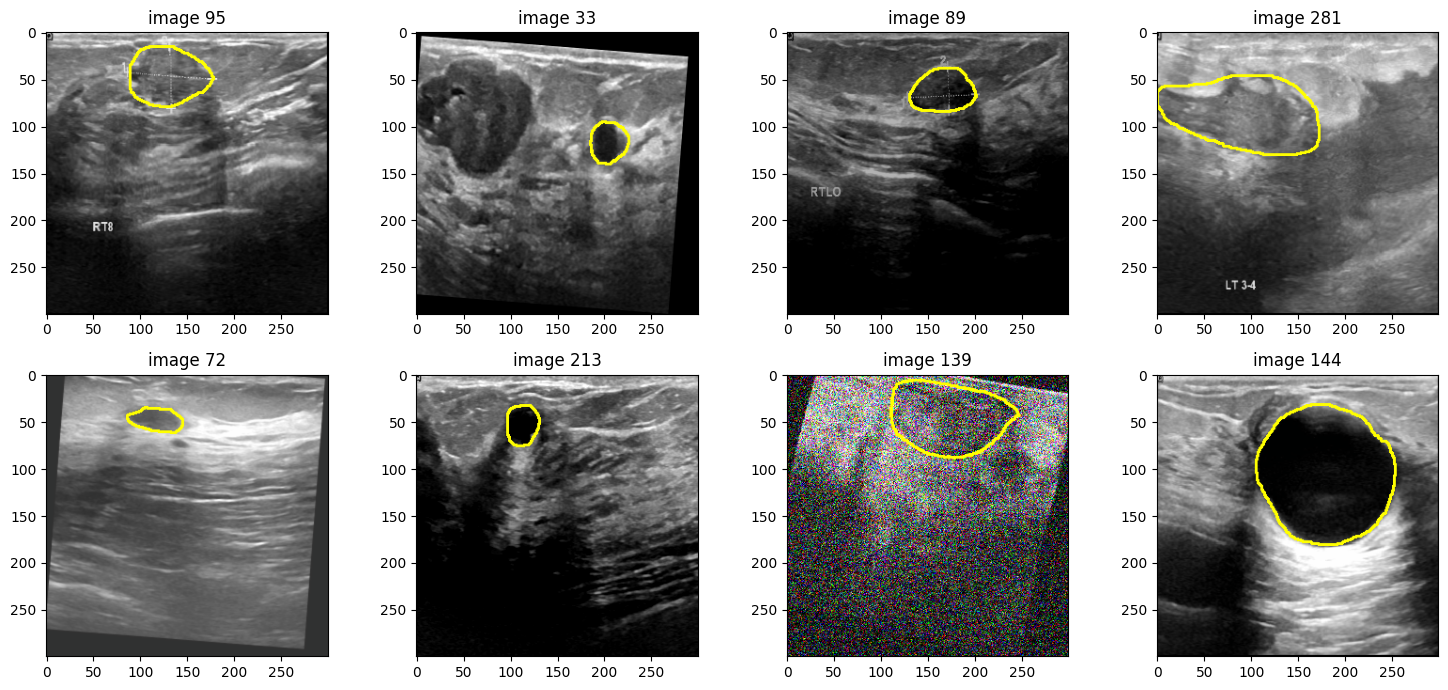

In [35]:
# plot some augmented images with mask
plt.figure(figsize=(15, 7))
for i in range(8):
  idx = np.random.randint(len(ben_train_loader.dataset))
  img, mask = ben_train_loader.dataset.__getitem__(idx)

  img = denormalize(img.permute(1,2,0).cpu().numpy())
  plt.subplot(2, 4, i+1)

  if len(mask.shape) == 3:
    imgray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
  else:
    imgray = np.array(mask)

  if imgray.max() <= 1:
      imgray = (imgray * 255).astype("uint8")
  else:
      imgray = imgray.astype("uint8")
  mask = denormalize(mask)
  _, threshold = cv2.threshold(imgray.copy(), 127, 255, cv2.THRESH_BINARY)
  contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

  contours_org_img = cv2.drawContours(img, contours, -1, (127, 255, 0), 2)

  plt.imshow(contours_org_img)
  plt.title(f"image {idx}")
plt.tight_layout()


In [19]:
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, stride=stride),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c)
        )

        # match dimensions for skip connection
        if in_c != out_c or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_c)
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        residual = self.skip(x)      # original path

        out = self.conv(x)           # transformed path

        out = out + residual
        out = self.relu(out)  #  RESIDUAL ADDED

        return out

**ResNet Encoder + U-Net Decoder (ResUNet)**
```
Input → Encoder (ResBlocks ↓) → Bottleneck
      → Decoder (↑ + Skip connections) → Output Mask
```

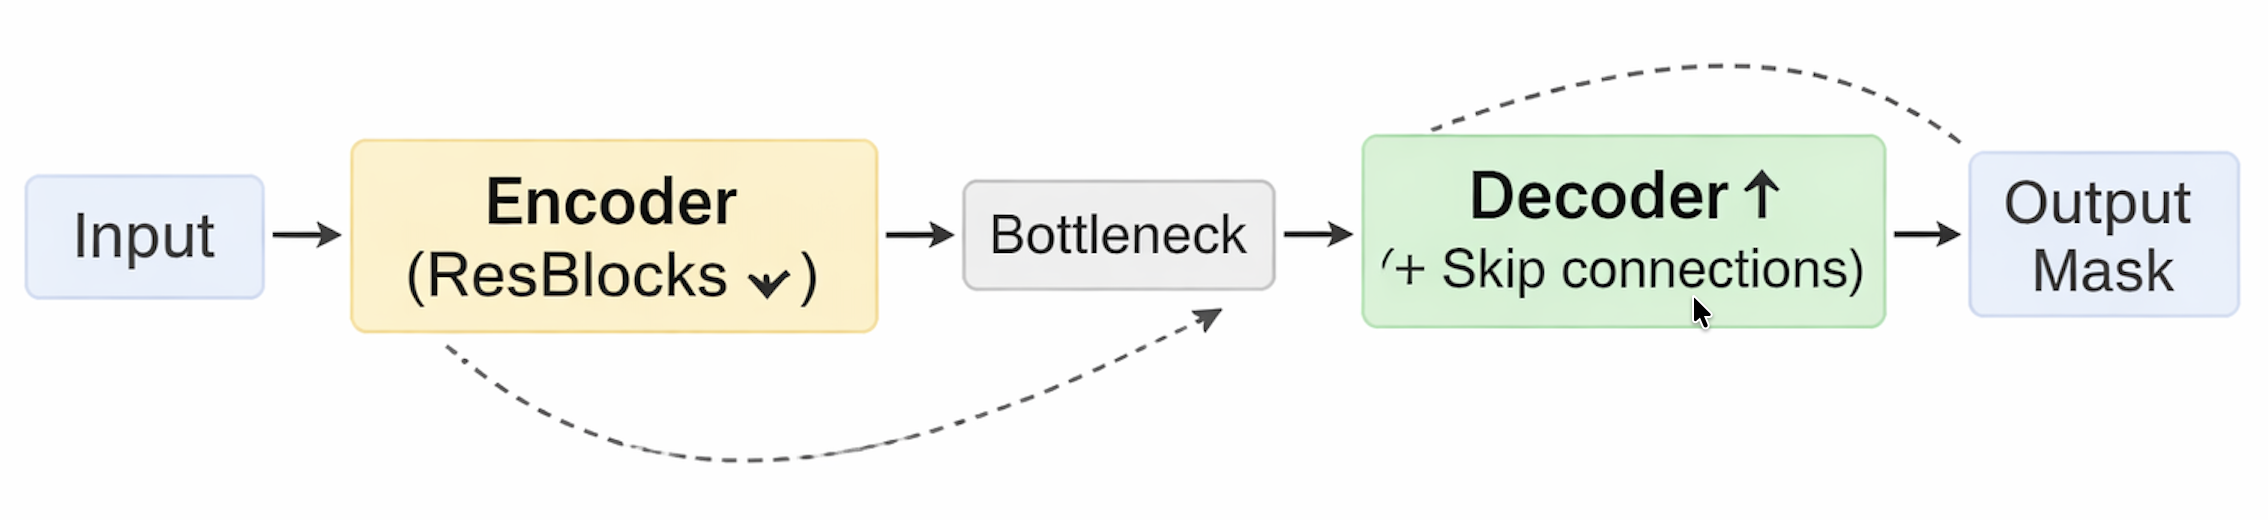

In [38]:
# Builing the network
class Cnn_network(nn.Module):
  def __init__(self, num_class):
    super(Cnn_network, self).__init__()

    # Encoder
    self.block1 = nn.Sequential(
        ResidualBlock(3, 32, stride=2),
        ResidualBlock(32, 32, stride=1)
    )

    self.block2 = nn.Sequential(
        ResidualBlock(32, 64, stride=2),
        ResidualBlock(64, 64, stride=1)
    )

    self.block3 = nn.Sequential(
        ResidualBlock(64, 128, stride=2),
        ResidualBlock(128, 128, stride=1)
    )

    self.block4 = nn.Sequential(
        ResidualBlock(128, 256, stride=2),
        ResidualBlock(256, 256, stride=1)
    )

    self.dropout = nn.Dropout2d(0.3)

    # Decoder
    self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
    self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
    self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
    self.up4 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)

    self.conv1 = ResidualBlock(256, 128, stride=1)
    self.conv2 = ResidualBlock(128, 64, stride=1)
    self.conv3 = ResidualBlock(64, 32, stride=1)
    self.conv4 = ResidualBlock(32, 32, stride=1)


    self.final = nn.Conv2d(32, 1, kernel_size=1)


  def forward(self, x):

    # Encoder
    x1 = self.block1(x)
    x2 = self.block2(x1)
    x3 = self.block3(x2)
    x4 = self.block4(x3) # <-- Bottleneck
    x4 = self.dropout(x4) # <-- reduce noise at bottleneck

    # Decoder
    x = self.up1(x4)
    x = nn.functional.interpolate(x, size=x3.shape[2:])
    x = torch.cat([x, x3], dim=1)
    x = self.conv1(x)

    x = self.up2(x)
    x = nn.functional.interpolate(x, size=x2.shape[2:])
    x = torch.cat([x, x2], dim=1)
    x = self.conv2(x)

    x = self.up3(x)
    x = nn.functional.interpolate(x, size=x1.shape[2:])
    x = torch.cat([x, x1], dim=1)
    x = self.conv3(x)

    x = self.up4(x)
    x = self.conv4(x)

    x = self.final(x)
    return x
net = Cnn_network(4).to(device)
net

Cnn_network(
  (block1): Sequential(
    (0): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Sequential(
        (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     

In [ ]:
# test the model
dumy_dataset = torch.randn(2, 3, 300, 300).to(device)
# test the model
pred = net(dumy_dataset)
pred

In [40]:
# define the compiler
optimizer = torch.optim.AdamW(params=net.parameters(), lr=0.0002, weight_decay=0.0001)
# ↑ (Adam with Weight Decay) decouples these, leading to better generalization more consistant decay

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, # Drops the learning rate when the validation loss stops improving
                                                       mode='min',
                                                       patience=2,
                                                       factor=0.5)

In [22]:
# Dice Loss
def dice_loss(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred) # Sigmoid because pred is logits

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    dice = (2. * intersection + smooth) / (union + smooth)

    return 1 - dice

def combined_loss(pred, target):
    bce = torch.nn.BCEWithLogitsLoss()(pred, target)
    dice = dice_loss(pred, target)
    loss = 0.6 * bce + 0.4 * dice # weighted loss combination.

    return loss



Dice coefficient is defined as:

$$
\text{Dice} = \frac{2|A \cap B|}{|A| + |B|}
$$

Where:

* **A** = predicted mask
* **B** = ground truth mask
* **|A ∩ B|** = overlap (intersection)
* **|A| + |B|** = total size of both masks

---

**🧠 Connection to IoU**

IoU is:

$$
\text{IoU} = \frac{|A \cap B|}{|A \cup B|}
$$

Dice is basically a *smoother, more forgiving version of IoU*.


**🧠 So we combine them**

$$
L = \alpha \cdot L_{BCE} + (1 - \alpha) \cdot L_{Dice}
$$



In [23]:
# training method
def train(data_loader, loss_fun, optimizer):
  # print(f'is training: {net.training}')
  size = len(data_loader.dataset)
  training_loss = 0
  number_of_batches = len(data_loader)

  net.train(mode=True) # set the model in the training mode
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    y = y.unsqueeze(1).float()
    # reset all the gradient
    optimizer.zero_grad()

    output = net(X) # <-- directly calling the forward method
    loss = loss_fun(output, y) # calculate the error
    # print(f"loss: {loss} output: {output.shape}")
    loss.backward() # compute the gradient
    # at this point we computed the gradient

    optimizer.step() # update the weights
    training_loss += loss.item()
    if (batch+1 == number_of_batches):
      print(f'Batch {batch+1}/{number_of_batches} | Loss: {loss.item():.4f}')

  return training_loss/number_of_batches


In [24]:
# Validate the model
def val_model(data_loader, loss_fun):
  val_loss = 0
  net.eval()
  with torch.no_grad(): # disable the grade calculation
    for data in data_loader:
      X, y = data
      X, y = X.to(device), y.to(device)
      y = y.unsqueeze(1).float()

      output = net(X)

      loss = loss_fun(output, y)
      val_loss += loss.item()
  return val_loss/len(data_loader)

In [372]:
img, label = ben_train_loader.dataset.__getitem__(0)
img.shape

torch.Size([3, 300, 300])

In [41]:
epoch = 12
history = {'tr_loss': [], 'val_loss': []}
best_val = float('inf')
patience = 3
counter = 0
best_epoch = 0
for i in range(epoch):
  print(f"Epoch {i}: ")
  tr_loss = train(ben_train_loader, combined_loss, optimizer)
  history['tr_loss'].append(tr_loss)
  avg_loss = val_model(ben_valid_loader, combined_loss)

  # update the learning rate
  scheduler.step(round(avg_loss, 4)) # <-- reduces noise sensitivity
  history['val_loss'].append(avg_loss)
  print(f"Validation loss: {avg_loss}")

  if avg_loss < best_val:
      best_val = avg_loss
      counter = 0
      best_epoch = i
      torch.save(net.state_dict(), "best_model.pth")
  else:
      counter += 1

  if counter >= patience:
      print("Early stopping!")
      break
print(f"Best model at epoch {best_epoch}")

Epoch 0: 
Batch 9/9 | Loss: 0.6684
Validation loss: 0.722888191541036
Epoch 1: 
Batch 9/9 | Loss: 0.6252
Validation loss: 0.7052578528722128
Epoch 2: 
Batch 9/9 | Loss: 0.5993
Validation loss: 0.6546878019968668
Epoch 3: 
Batch 9/9 | Loss: 0.5724
Validation loss: 0.5805500944455465
Epoch 4: 
Batch 9/9 | Loss: 0.5409
Validation loss: 0.5545629660288492
Epoch 5: 
Batch 9/9 | Loss: 0.5218
Validation loss: 0.5172449350357056
Epoch 6: 
Batch 9/9 | Loss: 0.4965
Validation loss: 0.4946656823158264
Epoch 7: 
Batch 9/9 | Loss: 0.4514
Validation loss: 0.4617011348406474
Epoch 8: 
Batch 9/9 | Loss: 0.4317
Validation loss: 0.45402530829111737
Epoch 9: 
Batch 9/9 | Loss: 0.4063
Validation loss: 0.44214949011802673
Epoch 10: 
Batch 9/9 | Loss: 0.4235
Validation loss: 0.42704445123672485
Epoch 11: 
Batch 9/9 | Loss: 0.4064
Validation loss: 0.39598949750264484
Best model at epoch 11


<Axes: >

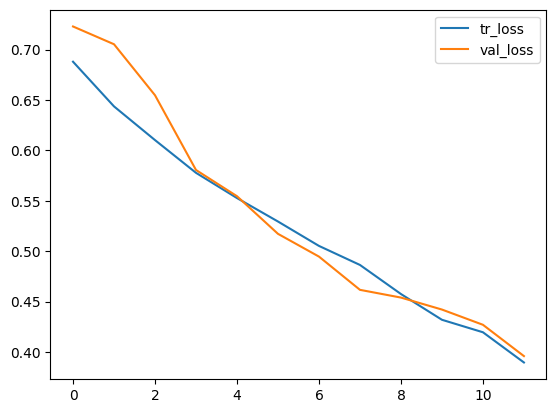

In [42]:
# Plot the loss curve
pd.DataFrame(history).plot()

In [43]:
model_path = '/content/drive/MyDrive/Healthcare/BUSI/mask6_with_dice_bce_loss(best1).pt'

In [44]:
# save the model
torch.save(net.state_dict(), model_path)

In [30]:
# load the model
model = Cnn_network(num_class=4).to(device)

state_dict = torch.load(model_path, weights_only=True, map_location=torch.device('cpu'))
model.load_state_dict(state_dict)

model.eval()

Cnn_network(
  (block1): Sequential(
    (0): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Sequential(
        (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     

In [27]:
# Get the test dataset
benign_test = Dataset(test_data, test_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline)
ben_test_loader = torch.utils.data.DataLoader(benign_test, shuffle=False, batch_size=16, drop_last=False, num_workers=2 )

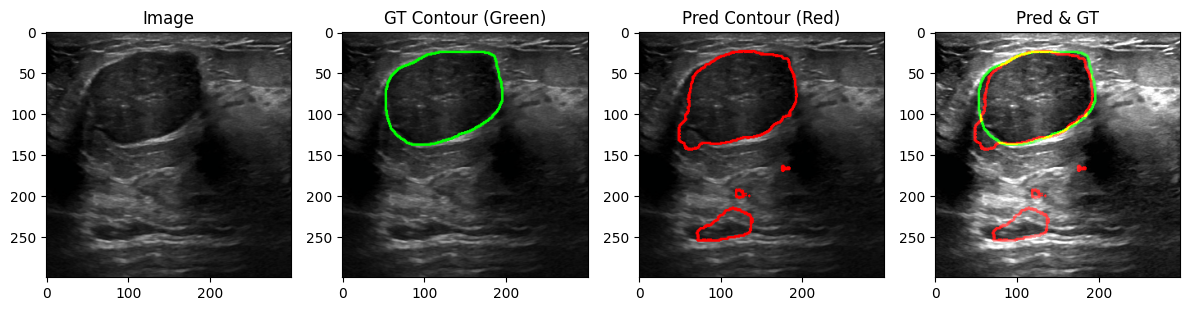

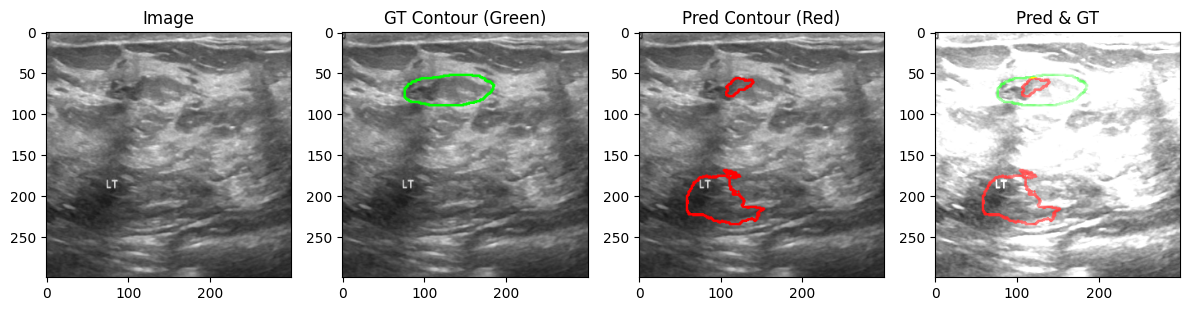

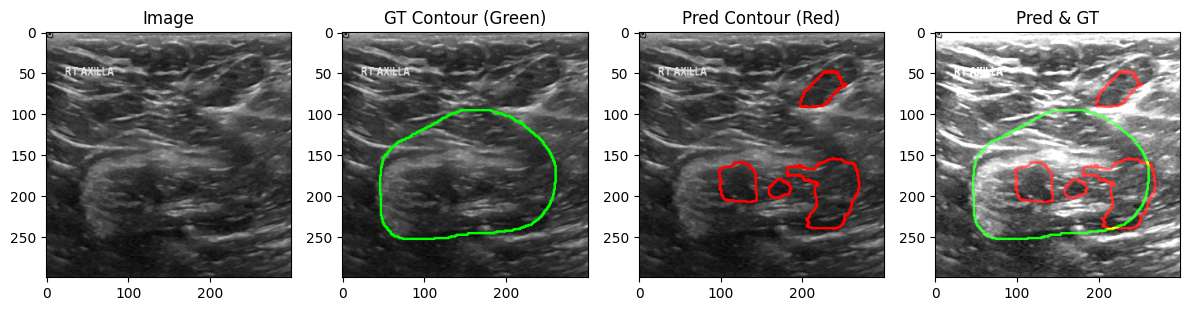

In [47]:
for _ in range(3):
  idx = np.random.randint(len(ben_test_loader.dataset))
  img, gt_mask = ben_test_loader.dataset[idx]

  with torch.no_grad():
      pred = net(img.unsqueeze(0).to(device))
      pred = torch.sigmoid(pred).squeeze().cpu().numpy()

  # image for display
  img_vis = denormalize(img.permute(1,2,0).cpu().numpy()).copy()

  # convert masks to binary uint8
  pred_mask = (pred > 0.5).astype(np.uint8)
  gt_mask = gt_mask.squeeze().cpu().numpy().astype(np.uint8)

  # ensure uint8
  pred_mask = (pred_mask * 255).astype(np.uint8)
  gt_mask = (gt_mask * 255).astype(np.uint8)

  # find contours
  pred_contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  gt_contours, _ = cv2.findContours(gt_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  # draw on image
  img_pred = img_vis.copy()
  img_gt = img_vis.copy()

  cv2.drawContours(img_pred, pred_contours, -1, (255, 0, 0), 2)  # RED = prediction
  cv2.drawContours(img_gt, gt_contours, -1, (0, 255, 0), 2)      # GREEN = GT

  # plot
  plt.figure(figsize=(12,8))

  plt.subplot(1,4,1)
  plt.imshow(img_vis)
  plt.title("Image")

  plt.subplot(1,4,2)
  plt.imshow(img_gt)
  plt.title("GT Contour (Green)")

  plt.subplot(1,4,3)
  plt.imshow(img_pred)
  plt.title("Pred Contour (Red)")

  plt.subplot(1,4,4)
  plt.imshow(img_pred+img_gt)
  plt.title("Pred & GT")

  plt.tight_layout()
  plt.show()